openEO provides a hosted computation interface on the cloud infrastructure itself. It can also be used to download data.

In [2]:
import pickle

import openeo
import xarray as xr
from zarr.storage import ZipStore

In [3]:
with open("../params.pkl", "rb") as fp:
    p = pickle.load(fp)

In [3]:
c = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [ ]:
datacube = c.load_collection(
    "SENTINEL2_L2A",
    temporal_extent=[p["start"], p["end"]],
    bands=["B08", "B11", "SCL"],
    max_cloud_cover=80,
)
datacube = datacube.filter_bbox(p["box_3035"], crs=3035)
datacube = datacube.resample_spatial(resolution=10, projection=3035)

In [6]:
datacube.download("openeo.zarr")

OpenEoApiError: [500] Internal: Server error: java.nio.file.FileSystemException: /tmp/openeo-pydrvr-85bhln9e.save_result.zarr/B03: Not a directory (ref: r-26062009474249c7b4a6a2ac4acca580)

Apparently there is an issue with a synchronous download of zarr data from the cdse openeo backend. While reporting that issue I got the hint that it might work as an asynchronous batch job. So we will try that next.

In [ ]:
%%time
job = datacube.create_job(out_format="zarr")
job.start_and_wait()
results = job.get_results()
result_files = results.download_files("data/")

0:00:00 Job 'j-26062010033146988a309be9a0f9f78c': send 'start'
0:00:02 Job 'j-26062010033146988a309be9a0f9f78c': created (progress 0%)
0:00:07 Job 'j-26062010033146988a309be9a0f9f78c': queued (progress 0%)
0:00:14 Job 'j-26062010033146988a309be9a0f9f78c': queued (progress 0%)
0:00:22 Job 'j-26062010033146988a309be9a0f9f78c': queued (progress 0%)
0:00:32 Job 'j-26062010033146988a309be9a0f9f78c': queued (progress 0%)
0:00:45 Job 'j-26062010033146988a309be9a0f9f78c': running (progress N/A)
0:01:00 Job 'j-26062010033146988a309be9a0f9f78c': running (progress N/A)
0:01:19 Job 'j-26062010033146988a309be9a0f9f78c': running (progress N/A)
0:01:44 Job 'j-26062010033146988a309be9a0f9f78c': running (progress N/A)
0:02:18 Job 'j-26062010033146988a309be9a0f9f78c': running (progress N/A)
0:02:55 Job 'j-26062010033146988a309be9a0f9f78c': running (progress N/A)
0:03:42 Job 'j-26062010033146988a309be9a0f9f78c': running (progress N/A)
0:04:41 Job 'j-26062010033146988a309be9a0f9f78c': running (progress N/

[PosixPath('data/out.zarr.zip'), PosixPath('data/job-results.json')]

This works but takes longer than odc-stac. We now have to unzip the zarr so we can read it.

In [ ]:
# Open the zip store directly
store = ZipStore(result_files[0], mode="r")
ds = xr.open_zarr(store)

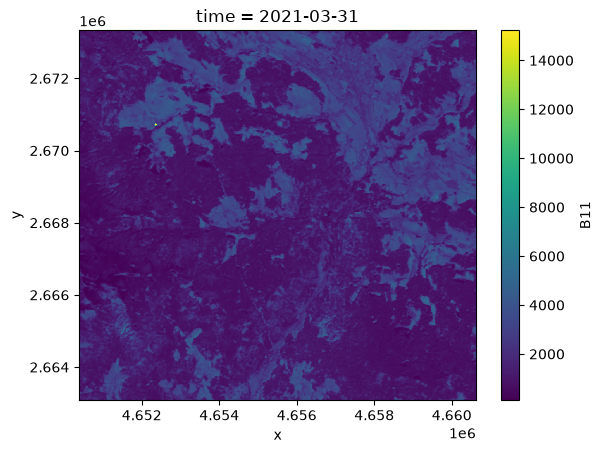

In [8]:
ds.B11.isel(time=22).plot();

Alternatively we can also try and get a netCDF file synchronously.

In [12]:
%%time
datacube.download("openeo.nc")

CPU times: user 592 ms, sys: 583 ms, total: 1.17 s
Wall time: 8min 58s


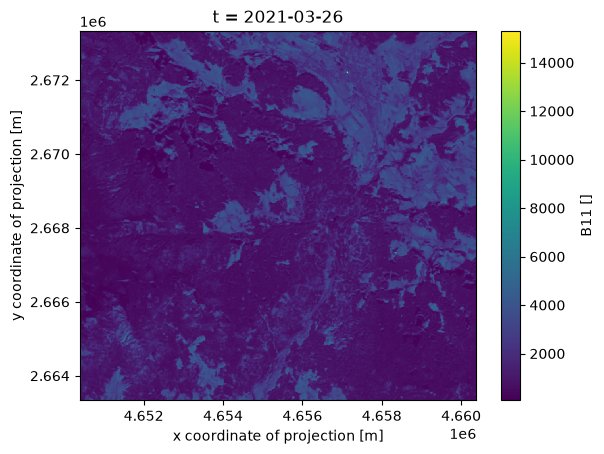

In [15]:
dataset = xr.open_dataset("openeo.nc")
dataset.B11.isel(t=22).plot();

Synchronously downloading a netcdf file works and is faster than the async batch job for the zarr data. But somehow the two approaches return different acquisitions. The netcdf shows the 26th of March as the 23nd acquisition and the zarr shows the 31st of March.

But keep in mind here, that getting the data with openeo does consume limited credits and is similarly fast as odc-stac.